In [1]:
import numpy as np
from ase.io import read
from ase.visualize import view
from ase.db import connect
import sys
import pandas as pd
import matplotlib.pyplot as plt
import copy

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection  import train_test_split
from scipy.optimize import least_squares, minimize, basinhopping

# from Helper_SurfEP_DirectFit_Dev import exportHostModel

#sys.path.append("/Users/Matt/pythonScripts/montemoregroup/src/montegroup/")
sys.path.append("/Users/hajar/Downloads/montemoregroup1/src/montegroup")
# from surfEP import surfEP
from ghit import GHIT
from coordsFunctions import snapCoords,findNeighborIndices


In [3]:
import importlib
import gnn_framework_surf2
importlib.reload(gnn_framework_surf2)

from gnn_framework_surf2 import GNNModel, GraphSample

In [4]:
### All input for data section should go here

### databases that already know the host binding atoms
databaseDir1 = '/Users/hajar/Downloads/Databases_PW91/'

databaseNames1 = ['hAdsProcessed.db','FProcessed.db','KProcessed.db',
               'nhxProcessed.db','nhxProcessed.db',
               'shxProcessed.db','shxProcessed.db',
               'chxProcessed.db','chxProcessed.db', 'chxProcessed.db','chxProcessed.db',
               'oxAdsProcessed.db','oxAdsProcessed.db','oxAdsProcessed.db','coProcessed.db'
                ]

databaseList1 = [connect(databaseDir1+databaseName) for databaseName in databaseNames1]

importGuestList1 = ['H','F','K',
                   'N','NH2',
                   'S','SH',
                   'C','Methyl', 'Methylene','Methylidyne', 
                   'O','Hydroxyl','Methoxy','CO'
                  ]

### databases that don't know the host binding atoms

#databaseDir2 = '/Users/Matt/Dropbox/Data/Databases_PW91/'

databaseDir2 = '/Users/hajar/Downloads/Databases_PW91/'
databaseNames2 = ['DissFinal.db','DissFinal.db','DissFinal.db','DissFinal.db',
                  'DissFinal.db','DissFinal.db','DissFinal.db','MoreMethylTop_Processed.db','MoreOH_Processed.db']
databaseList2 = [connect(databaseDir2+databaseName) for databaseName in databaseNames2]
importGuestList2 = ['CH4TS','CH3TS','CH2TS','CHTS',
                    'OHTS','H2OTS','COTS', 'Methyl','Hydroxyl']
gasPhaseEnList2 = [-24.091421,-18.176726,-12.058483,-6.102109,-7.579404,-14.26184735,-14.82331288,None,None]

bareSurfNewDB = connect(databaseDir2+'MSRNew12.db') 
bareSurfNew2DB = connect(databaseDir2+'bareSurfNew.db')

In [5]:
### Get adsorption energy, binding site, binding elements, etc. Put in datafram (df)

d = []
atomsList = []

for database,inputGuest in zip(databaseList1,importGuestList1):
    for row in database.select():
#         print(row.get('guest_name'))
        if 'NiPt' in row.get('directory') or 'Sandwich' in row.get('directory') or 'HydrogenTi3inOs' in row.get('directory') or 'NH2ReonPt' in row.get('directory') or 'Step' in row.get('directory'):
            print(row.get('directory')+' skipped')
            continue
        if row.get('guest_name') != inputGuest:
            continue
        if 'Sn' in row.get('symbols') or 'Zn' in row.get('symbols'):
            continue
        print(row.get('directory'))
        print(row.get('guest_name'))
        atoms = row.toatoms()
        atoms.set_pbc(True)
        atomsList.append(atoms)
        symbols = np.array(atoms.get_chemical_symbols())
#         if symbols[0] != inputGuest: print('WARNING: Code probably went wrong because '+'guestAtom'+' is not first atom.')
        ghit = GHIT(row.toatoms())
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        print(ghit)
        print(row)
        try:
            host_binding_atoms_bare = row.data.get('atoms_adsorbed_to')
            ### TODO: Fix next line. It will almost certainly cause problems at some point. Should probably just detect host binding atoms in all cases.
            host_binding_atoms_adsorbed = np.array(host_binding_atoms_bare) + len(ghit.get_guest_atoms())
        except (ValueError, AttributeError):
            ghit.find_host_binding_atoms()
            host_binding_atoms_adsorbed = ghit.get_host_binding_atoms()[0]
        

        print(ghit.get_guest_atoms())
#         ghit.host_binding_atoms()
#         host_binding_atoms = ghit.get_host_binding_atoms()[0]
#         print(host_binding_atoms)
        host_binding_elements = symbols[list(host_binding_atoms_adsorbed)]
#         print(symbols[row.data.get('atoms_adsorbed_to')+1])
        #print(row.__dict__)
        #host_binding_atoms_bare = np.array(host_binding_atoms_bare,dtype='int')
        d.append({'directory':row.get('directory')[40:],'adsorption_energy':row.get('adsorption_energy'),
                  'site_name':row.get('site_name'), 'host_name':row.get('host_name'),
                'guest_name':row.get('guest_name'),'host_binding_elements':host_binding_elements,
                 'host_binding_atoms_ads':host_binding_atoms_adsorbed})

for database,inputGuest,gasPhaseEn in zip(databaseList2,importGuestList2,gasPhaseEnList2):
    for row in database.select():
#         print(row.get('guest_name'), row.get('host_name'))
        if row.get('guest_name') != inputGuest:
            continue
        print(row.get('directory'))
        print(row.get('guest_name'))
        siteName = 'top' ### BIG ASSUMPTION!!!!! TODO: FIX THIS!!!!
        atoms = row.toatoms()
        atoms.set_pbc(True)
        atomsList.append(atoms)
        symbols = np.array(atoms.get_chemical_symbols())
        ghit = GHIT(row.toatoms())
        ghit.set_pbc(True)
#         ghit.wrap(center=ghit.positions[0])
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        print('all guest:',ghit.get_guest_atoms())
        ghit.find_guest_binding_atoms(distance_gap_tolerance=0.5,check_saturation=True)
        print('gba',ghit.get_guest_binding_atoms())
        ghit.set_binding_sites(['ontop' for at in ghit.get_guest_binding_atoms()])
        ghit.find_host_binding_atoms()
        print(ghit.get_binding_sites())
        select_hba = [0]
        host_binding_atoms_adsorbed = np.array([item for sublist in ghit.get_host_binding_atoms() for item in sublist])[select_hba]
        print(host_binding_atoms_adsorbed)
        host_binding_elements = symbols[list(host_binding_atoms_adsorbed)]
        

        if gasPhaseEn is None: 
            adsEn = row.get('adsorption_energy')
        else:
            try:
                bareSurfRow = bareSurfNewDB.get('guest_name=BareSurf,host_name='+row.get('host_name')) #
                adsEn = row.get('energy') - bareSurfRow.get('energy') - gasPhaseEn
            except KeyError:
                bareSurfRow = bareSurfNew2DB.get('host_name='+row.get('host_name')) #
                adsEn = row.get('energy') - bareSurfRow.get('energy') - gasPhaseEn               
        d.append({'directory':row.get('directory')[40:],'adsorption_energy':adsEn,
                  'site_name':siteName, 'host_name':row.get('host_name'),
                'guest_name':row.get('guest_name'),'host_binding_elements':host_binding_elements,
                 'host_binding_atoms_ads':host_binding_atoms_adsorbed,
                 'guest_binding_atoms':ghit.get_guest_binding_atoms(), 
                 })
        
df = pd.DataFrame(d)

/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg/Bridge
H
GHIT(symbols='HAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., constraint=FixAtoms(indices=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]), calculator=SinglePointCalculator(...))
<AtomsRow: formula=Ag36H, keys=site_name,adsorption_energy,host_name,directory,guest_name>
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg/FHollow
H
GHIT(symbols='HAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., constraint=FixAtoms(indices=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]), calculator=SinglePointCalculator(...))
<AtomsRow: formula=Ag36H, keys=site_name,adsorption_energy,host_name,dir

/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/SulfurAg/Bridge
S
GHIT(symbols='SAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., calculator=SinglePointCalculator(...))
<AtomsRow: formula=Ag36S, keys=site_name,adsorption_energy,host_name,directory,guest_name>
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/SulfurAg/FHollow
S
GHIT(symbols='SAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., calculator=SinglePointCalculator(...))
<AtomsRow: formula=Ag36S, keys=site_name,adsorption_energy,host_name,directory,guest_name>
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/SulfurAg/HHollow
S
GHIT(symbols='SAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.

/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


gba [36 39]
['ontop' 'ontop']
[6]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissSc_Ag
CH4TS
all guest: [0 1 2 3 4]
gba [0 3]
['ontop' 'ontop']
[11]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissTa_Ag
CH4TS
all guest: [0 1 2 3 4]
gba [0 3]
['ontop' 'ontop']
[11]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissTi2_Ag
CH4TS
all guest: [0 1 2 3 4]
gba [0 3]
['ontop' 'ontop']
[11]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissV_Cu
CH4TS
all guest: [36 37 38 39 40]
gba [36 39]
['ontop' 'ontop']
[6]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissZr_Ag
CH4TS
all guest: [0 1 2 3 4]
gba [0 3]
['ontop' 'ontop']
[11]
/home/nwaokorie/Desktop/DFT/Calculations/PyMatGenStuff/CH3Dissociation/CH3DissNi
CH3TS
all guest: [0 1 2 3]
gba [0 2]
['ontop' 'ontop']
[11]
/home/nwaokorie/Desktop/DFT/Calculations/PyMatGenStuff/CH3Dissociation/CH3DissRu
CH3TS
all guest: [0 1 2 3]
gba [0 2]
['ontop' 'ontop']
[12]
/home/nwaokorie/Desktop/DFT/Calculations/PyMatGenStuff/CH3Dissociation/CH3DissRh
CH3TS
all guest: [0 1 

In [6]:
print(len(df),len(atomsList))
display(df[df['guest_name'].str.contains("OH")]) #[['formulas','error','adsorption_energy','pred_adsorption_energy']]
print(d[1478])

1776 1776


,directory,adsorption_energy,site_name,host_name,guest_name,host_binding_elements,host_binding_atoms_ads,guest_binding_atoms
1467,/PyMatGenStuff/MSRProject/OHDissociation/OHDissNi,-2.481004,top,Ni,OHTS,[Ni],[7],"[0, 1]"
1468,/PyMatGenStuff/MSRProject/OHDissociation/OHDissRu,-2.674866,top,Ru,OHTS,[Ru],[6],"[0, 1]"
1469,/PyMatGenStuff/MSRProject/OHDissociation/OHDissRh,-2.139037,top,Rh,OHTS,[Rh],[9],"[0, 1]"
1470,/PyMatGenStuff/MSRProject/OHDissociation/OHDissAg,-0.400234,top,Ag,OHTS,[Ag],[7],"[0, 1]"
1471,/PyMatGenStuff/MSRProject/OHDissociation/OHDissAu,-0.070451,top,Au,OHTS,[Au],[8],"[0, 1]"
1472,/PyMatGenStuff/MSRProject/OHDissociation/OHDissCu,-1.683246,top,Cu,OHTS,[Cu],[7],"[0, 1]"
1473,/PyMatGenStuff/MSRProject/OHDissociation/OHDissIr,-1.550183,top,Ir,OHTS,[Ir],[8],"[0, 1]"
1474,/PyMatGenStuff/MSRProject/OHDissociation/OHDissPd,-1.207190,top,Pd,OHTS,[Pd],[10],"[0, 1]"
1475,/PyMatGenStuff/MSRProject/OHDissociation/OHDissPt,-1.428230,top,Pt,OHTS,[Pt],[8],"[0, 1]"
1476,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-1.892880,top,Ir_Ag,OHTS,[Ir],[8],"[0, 1]"


{'directory': '/PyMatGenStuff/MSRProject/OHDissociation/OHDissTi_Ag', 'adsorption_energy': -4.027679169999995, 'site_name': 'top', 'host_name': 'Ti_Ag', 'guest_name': 'OHTS', 'host_binding_elements': array(['Ti'], dtype='<U2'), 'host_binding_atoms_ads': array([8]), 'guest_binding_atoms': array([0, 1])}


In [7]:
rowNum = 1485 #1473 #1478
#bareDB = connect('/Users/Matt/Dropbox/Data/Databases_PW91/bareSurfNew.db') #MoreBare.db, MSRNew12.db, bareSurfNew.db, bareSurfClean.db
bareDB = connect('/Users/hajar/Downloads/Databases_PW91/bareSurfNew.db')
display(df.iloc[rowNum])
adsAtomsTemp = atomsList[rowNum]

try: print('mag mom ads:', adsAtomsTemp.get_magnetic_moment())
except Exception: print('no mag mom ads')
# print('energy ads',adsAtomsTemp.get_potential_energy())
adsAtomsTemp.wrap(center = (0.3,0.3,0.8))
# view(adsAtomsTemp)

bareSurfRow = bareDB.get('host_name='+df.iloc[rowNum]['host_name']) #guest_name=BareSurf or None
try: print(bareSurfRow.get('directory')[-30:])
except KeyError: print('no dir')

try: print('mag mom bare:', bareDB.get_magnetic_moment())
except Exception: print('no mag mom bare')
# print('energy bare',bareAtomsTemp.get_potential_energy())
bareAtomsTemp = bareSurfRow.toatoms()
bareAtomsTemp.wrap(center = (0.3,0.3,0.8))
# view(bareAtomsTemp)

directory                 issRu_Cu
adsorption_energy        -1.914379
site_name                      top
host_name                    Ru_Cu
guest_name                    OHTS
host_binding_elements         [Ru]
host_binding_atoms_ads         [6]
guest_binding_atoms       [36, 37]
Name: 1485, dtype: object

no mag mom ads
ses_PW91/CH4Diss/BareSurfRu_Cu
no mag mom bare


In [8]:
dropList = [1629, 1550, 1691, 1692, 1551, 1593, 1552, 1592, 1591, 
            1594, 1595, 1629, 1693, 1696, 1697, 1698, 1708, 847, 848, 1554, 1628] 
dropList = list(np.sort(np.unique(dropList))[::-1])

df.iloc[dropList]

df.drop(dropList,inplace=True)
print(len(df))

for num in dropList:
    del atomsList[num]
    
len(atomsList), len(dropList)

df.reset_index(drop=True, inplace=True) 

1756


In [9]:
df.loc[1492]

directory                 /PyMatGenStuff/MSRProject/H2ODissociation/H2OD...
adsorption_energy                                                  0.959284
site_name                                                               top
host_name                                                                Cu
guest_name                                                            H2OTS
host_binding_elements                                                  [Cu]
host_binding_atoms_ads                                                 [11]
guest_binding_atoms                                                  [0, 1]
Name: 1492, dtype: object

In [10]:
dfOrig = copy.deepcopy(df)
df = dfOrig.loc[(dfOrig['adsorption_energy']<2.5)&(dfOrig['adsorption_energy']>-20)]
print(len(df))

# Keep atomsList in sync with the filtered dataframe
atomsListOrig = copy.deepcopy(atomsList)
atomsList = [atomsListOrig[i] for i in df.index]
# Reset dataframe index to match atomsList ordering
df.reset_index(drop=True, inplace=True)

1750


In [11]:
atomsList[0]

Atoms(symbols='HAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], constraint=FixAtoms(indices=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]), calculator=SinglePointCalculator(...))

In [12]:
def make_edge_list(atoms, verbose=False):
    """
    Create an edge list suitable for a convolutional graph neural network.
    Edges are classified as:
    - 'SS': surface-surface (host-host connections)
    - 'AA': adsorbate-adsorbate (guest-guest connections)
    - 'SA_bond': surface-adsorbate bond (binding connections between host and guest)
    
    Uses GHIT to identify guest atoms and binding pairs.
    Uses ASE NeighborList with adaptive cutoffs for surface atoms based on second-nearest neighbors.
    
    Parameters:
    - verbose: If True, prints cutoffs per element and neighbor counts per atom.
    """
    from ase.neighborlist import NeighborList
    from ase.data import covalent_radii
    from collections import defaultdict
    import numpy as np
    
    # Initialize GHIT and find atoms
    ghit = GHIT(atoms)
    ghit.find_guest_atoms(guest_elements=['C', 'O', 'H', 'N', 'F', 'S', 'K'])
    guest_atoms = set(ghit.get_guest_atoms())
    host_atoms = set(range(len(atoms))) - guest_atoms
    
    # Find binding atoms for SA_bond
    ghit.find_guest_binding_atoms(distance_gap_tolerance=0.5, check_saturation=True)
    ghit.find_host_binding_atoms()
    
    guest_binding = ghit.get_guest_binding_atoms()
    host_binding_lists = ghit.get_host_binding_atoms()
    
    # Create SA_bond edges (undirected)
    sa_edges = []
    for gb, hb_list in zip(guest_binding, host_binding_lists):
        for hb in hb_list:
            sa_edges.append((min(gb, hb), max(gb, hb), 'SA_bond'))
    
    # Create cutoffs
    symbols = atoms.get_chemical_symbols()
    cutoffs = []
    host_indices = list(host_atoms)
    for i in range(len(atoms)):
        if i in host_atoms:
            # Adaptive cutoff based on second-nearest surface neighbor
            dists = atoms.get_distances(i, host_indices, mic=True)
            sorted_dists = sorted(dists)
            second_nn = sorted_dists[1]  # Second smallest distance (first is 0)
            cutoffs.append(1.05 * second_nn  * 0.5) # 0.5 for diameter to radius
        else:
            # Fixed cutoff for guest atoms
            cutoffs.append(covalent_radii[atoms[i].number] * 1.1 + 0.1)
    
    if verbose:
        # Print cutoffs per element for troubleshooting (approximate for guests)
        cutoff_dict = defaultdict(list)
        for i, cutoff in enumerate(cutoffs):
            element = symbols[i]
            cutoff_dict[element].append(cutoff)
        print("Neighbor cutoffs per element (surface: adaptive, guest: fixed):")
        for element in sorted(cutoff_dict.keys()):
            cuts = cutoff_dict[element]
            if len(cuts) == 1:
                print(f"  {element}: {cuts[0]:.3f} Å")
            else:
                print(f"  {element}: {min(cuts):.3f} - {max(cuts):.3f} Å")
    
    nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
    nl.update(atoms)
    
    edges = []
    for i in range(len(atoms)):
        neighbors = nl.get_neighbors(i)[0]
        for j in neighbors:
            if i < j:  # Avoid duplicates
                if i in host_atoms and j in host_atoms:
                    edges.append((i, j, 'SS'))
                elif i in guest_atoms and j in guest_atoms:
                    edges.append((i, j, 'AA'))
    
    if verbose:
        print("Neighbor counts per atom:")
        for i in range(len(atoms)):
            count = len(nl.get_neighbors(i)[0])
            print(f"  Atom {i} ({symbols[i]}): {count} neighbors")
    
    # Combine all edges
    edges.extend(sa_edges)
    return edges

In [13]:
make_edge_list(atomsList[10],verbose=True)

Neighbor cutoffs per element (surface: adaptive, guest: fixed):
  Au: 1.507 - 1.534 Å
  H: 0.441 Å
  Ti: 1.446 - 1.474 Å
Neighbor counts per atom:
  Atom 0 (H): 1 neighbors
  Atom 1 (Au): 10 neighbors
  Atom 2 (Au): 9 neighbors
  Atom 3 (Au): 9 neighbors
  Atom 4 (Ti): 9 neighbors
  Atom 5 (Ti): 9 neighbors
  Atom 6 (Ti): 9 neighbors
  Atom 7 (Ti): 9 neighbors
  Atom 8 (Ti): 9 neighbors
  Atom 9 (Ti): 9 neighbors
  Atom 10 (Ti): 12 neighbors
  Atom 11 (Ti): 12 neighbors
  Atom 12 (Ti): 12 neighbors
  Atom 13 (Ti): 12 neighbors
  Atom 14 (Ti): 12 neighbors
  Atom 15 (Ti): 12 neighbors
  Atom 16 (Ti): 12 neighbors
  Atom 17 (Ti): 12 neighbors
  Atom 18 (Ti): 12 neighbors
  Atom 19 (Ti): 12 neighbors
  Atom 20 (Ti): 12 neighbors
  Atom 21 (Ti): 12 neighbors
  Atom 22 (Ti): 12 neighbors
  Atom 23 (Ti): 12 neighbors
  Atom 24 (Ti): 12 neighbors
  Atom 25 (Ti): 12 neighbors
  Atom 26 (Ti): 12 neighbors
  Atom 27 (Ti): 12 neighbors
  Atom 28 (Ti): 9 neighbors
  Atom 29 (Ti): 9 neighbors
  Ato

/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


[(1, np.int64(6), 'SS'),
 (1, np.int64(8), 'SS'),
 (1, np.int64(14), 'SS'),
 (1, np.int64(4), 'SS'),
 (1, np.int64(5), 'SS'),
 (1, np.int64(7), 'SS'),
 (1, np.int64(9), 'SS'),
 (1, np.int64(10), 'SS'),
 (1, np.int64(15), 'SS'),
 (2, np.int64(4), 'SS'),
 (2, np.int64(5), 'SS'),
 (2, np.int64(6), 'SS'),
 (2, np.int64(7), 'SS'),
 (2, np.int64(8), 'SS'),
 (2, np.int64(9), 'SS'),
 (2, np.int64(11), 'SS'),
 (2, np.int64(12), 'SS'),
 (2, np.int64(13), 'SS'),
 (3, np.int64(5), 'SS'),
 (3, np.int64(6), 'SS'),
 (3, np.int64(16), 'SS'),
 (3, np.int64(17), 'SS'),
 (3, np.int64(18), 'SS'),
 (3, np.int64(8), 'SS'),
 (3, np.int64(9), 'SS'),
 (3, np.int64(4), 'SS'),
 (3, np.int64(7), 'SS'),
 (4, np.int64(5), 'SS'),
 (4, np.int64(7), 'SS'),
 (4, np.int64(10), 'SS'),
 (4, np.int64(12), 'SS'),
 (4, np.int64(18), 'SS'),
 (4, np.int64(8), 'SS'),
 (5, np.int64(6), 'SS'),
 (5, np.int64(10), 'SS'),
 (5, np.int64(11), 'SS'),
 (5, np.int64(17), 'SS'),
 (5, np.int64(9), 'SS'),
 (6, np.int64(8), 'SS'),
 (6, np.in

In [14]:
def snapCoords(coordsIn,idealCoords,cell):
    import ase
    import ase.geometry
    import numpy as np

    '''Returns the snapped coords.'''
    coordsNew = np.zeros([len(coordsIn),3]) 
    whereInideal = []
    
    if len(coordsIn) != 36 or len(idealCoords) != 36:
        print('Wrong dimension')
   
    for whichAtom in range(0,len(coordsIn)):
        
        #get_distance
        list_listOfDistances = ase.geometry.get_distances(coordsIn[whichAtom:whichAtom+1],idealCoords,cell=cell,pbc=True)[1]
        
    
        #get index of the minimum distance
        whereInIdeal=np.argmin(list_listOfDistances)
        
        #check if the any of the index is already used
        while whereInIdeal in whereInideal:
            list_listOfDistances[0][whereInIdeal] = float('inf')
            whereInIdeal=np.argmin(list_listOfDistances)
        
        
        #append new index
        whereInideal.append(np.argmin(list_listOfDistances))
        coordsNew[whichAtom] = (idealCoords[whereInIdeal])
    
        if len(whereInideal) == len(coordsIn):
            return coordsNew

def ideal_lattice(atoms,structure):
    'return snapped atoms only work for certain dimensions'
    import sys 
    sys.path.append("/Users/gboladekayode/pythonScript/montemoregroup")
    from ase import Atoms
    import numpy as np
    from ase.visualize import view
    from ase.build import hcp0001,fcc111
    from ghit import GHIT
    import ase
    
    
    ghit = GHIT(atoms)

    
    ghit.determine_layers(use_layer=True,atoms_per_layer=9)
    
    #bottom-top
    layer_1 = sorted(ghit.get_atom_layers()[0][1])
    layer_2 = sorted(ghit.get_atom_layers()[0][2])
    layer_3 = sorted(ghit.get_atom_layers()[0][3])
    layer_4 = sorted(ghit.get_atom_layers()[0][4])

    
    symbols = atoms.get_chemical_symbols()
    all_distance = atoms.get_all_distances()
    all_distance.sort(axis=1)
    coordsIn = atoms.get_positions()
    vacuum = np.min(atoms.get_positions()[:,2])
    cell = atoms.get_cell()
    size = (3,3,4)
    
    if structure == 'FCC':
        
        #the first layer does not move
        diameter = all_distance[layer_1[8],1]
        

        a=diameter*2/np.sqrt(2)

        
        build_atoms = ase.build.fcc111('Cu',size,a=a, vacuum=vacuum)
    
        idealCoords = build_atoms.get_positions()
    
        sort_2_layer_ideal = np.sort(idealCoords[9:18],axis=0)
        
        sort_2_layer_old = np.sort(coordsIn[layer_2],axis=0)
        
        difference_x = sort_2_layer_old[:,0]-sort_2_layer_ideal[:,0]
        difference_y = sort_2_layer_old[:,1]-sort_2_layer_ideal[:,1] 

        idealCoords[9:18] = coordsIn[layer_2]
        
        idealCoords[18:27,0] += difference_x
        idealCoords[18:27,1] -= difference_y
        
        

        positions = snapCoords(coordsIn,idealCoords,cell)
        snapped_atoms = Atoms(symbols,positions=positions,cell=cell,pbc=True)
        
        
        return(snapped_atoms)
     
    if structure == 'HCP':
        
        #diameter with different layer. assumming the side diameter is smaller than the diameter
        side_diameter = all_distance[layer_1[8],1]

        #diameter within the same layer
        last_layer_distance = atoms.get_distances(layer_1[8],range(layer_1[0],layer_1[8]), mic=False, vector=False)
        last_layer_distance.sort()
        diameter = last_layer_distance[0]

        c = 2*np.sqrt(2/3)*diameter*(side_diameter/diameter)

        build_atoms = ase.build.hcp0001('Cu', size, a=diameter, c=c, vacuum=vacuum, orthogonal=False, periodic=False)

        idealCoords = build_atoms.get_positions()
        
        
        difference = coordsIn[layer_1]-idealCoords[0:9] 
        idealCoords[0:9] = coordsIn[layer_1]
        idealCoords[18:27] += difference

        positions = snapCoords(coordsIn,idealCoords,cell)
        snapped_atoms = Atoms(symbols,positions=positions,cell=cell,pbc=True)
        
        return(snapped_atoms)


In [15]:
bareSurfList = []
host_binding_atoms_bare = []

for atoms,host_binding_atoms_ads in zip(atomsList,df.host_binding_atoms_ads.values):
    atomsCopy = copy.deepcopy(atoms)
#     print(atomsCopy.get_chemical_formula())
    ghit = GHIT(atomsCopy)
    ghit.find_guest_atoms(guest_elements=['H','F','K','N','S','C','O'])
#     print(ghit.get_host_atoms())
    atomsCopy.set_constraint()
    atomsNew = atomsCopy[ghit.get_host_atoms()]
    
    hbub = ghit.corresponding_host_atom(host_binding_atoms_ads, atomsNew)
    host_binding_atoms_bare.append(hbub)
#     for i in ghit.get_guest_atoms(): #May not work if more than one guest atom
#         atomsCopy.pop(i)
    atomsNew.wrap(center=(0.4,0.4,0.8))
    #TODO: Snap to grid here.
   # bareSurfList.append(atomsCopy)
    FCC_structure = ideal_lattice(atomsNew,'FCC')
    HCP_structure = ideal_lattice(atomsNew,'HCP')
    difference_fcc = np.sum(abs(atomsNew.get_all_distances() - FCC_structure.get_all_distances()))
    difference_hcp = np.sum(abs(atomsNew.get_all_distances() - HCP_structure.get_all_distances()))

    if difference_fcc >= difference_hcp:
        bareSurfList.append(HCP_structure)
    else:
        bareSurfList.append(FCC_structure)

print(len(bareSurfList))

1750


In [16]:
df = df.copy()
df['host_binding_atoms_bare'] = host_binding_atoms_bare


In [17]:
for surf in bareSurfList:
    if len(surf.get_chemical_symbols()) != 36:
        print(surf.get_chemical_symbols())

In [18]:
import sys
sys.path.append('../surfep/algorithms')



In [19]:
import os

# Suppose you know the folder name
surfep_folder = 'surfep'

# Current working directory
cwd = os.getcwd()
print("Current working directory:", cwd)

# Absolute path to surfep folder
surfep_path = os.path.join(cwd, surfep_folder)
print("Absolute path to surfep:", os.path.abspath(surfep_path))


Current working directory: /Users/hajar/gcnn
Absolute path to surfep: /Users/hajar/gcnn/surfep


In [20]:
import sys
sys.path.append('/Users/hajar/gcnn/surfep/algorithms')

from surfEP import surfEP


In [21]:
import pandas as pd
import os

element_data_file = '/Users/hajar/gcnn/surfep/data/PureElementData.csv'  # adjust if your repo uses different file
pureElementDataFrame = pd.read_csv(element_data_file, index_col=0)


In [22]:
#TODO: get surface atoms in a better way
### Maybe TODO: apply scaling to the features here so we can do ridge in a fair way.
### https://stackoverflow.com/questions/64567464/mask-0-values-during-normalization 

scaleECond = 10**-7 ###Puts conductivity on a more similar scale to other params.

### Calculates features of bare surface, adds to dataframe (df)
surfaceIndicesList = [[0,1,2,3,4,5,6,7,8,9] for bareSurf in bareSurfList]

adsPredictor = surfEP(
    verbose=False,
    jsonDirectory='/Users/hajar/gcnn/surfep/data/JSONFiles/',
    elementDataDirectory='/Users/hajar/gcnn/surfep/data/'
)

sdCouplingList, dFillingDiffList, eCondDiffList = adsPredictor.featuresForES(bareSurfList,surfaceIndicesList)

dFillingList = []
for surfaceIndices,bareSurf in zip(surfaceIndicesList,bareSurfList):
    surfaceElements = np.array(bareSurf.get_chemical_symbols())[surfaceIndices]
    dFillingSurf = [pureElementDataFrame.loc[element,'dFillingIdealized'] for element in surfaceElements]
    dFillingList.append(dFillingSurf)
    
df['sd_coupling_all'] = sdCouplingList
df['d_filling_n_all'] = dFillingDiffList
df['e_conductivity_n_all'] = [eCondDiff*scaleECond for eCondDiff in eCondDiffList]
df['d_filling_central_all'] = dFillingList

def selectFeature(df,feature):
    selectedList = []
    try:
        for index,row in df.iterrows():
            selectedList.append(np.array(row[feature])[row['host_binding_atoms_bare']])
        return selectedList
    except IndexError as error:
        print(error,': ',index, row['directory'])
        print(np.array(row[feature]))
        print(row['host_binding_atoms'])

df['sd_coupling'] = selectFeature(df,'sd_coupling_all')
df['d_filling_n'] = selectFeature(df,'d_filling_n_all')
df['e_conductivity_n'] = selectFeature(df,'e_conductivity_n_all')
df['d_filling_central'] = selectFeature(df,'d_filling_central_all')
df['d_filling_mult'] = df['d_filling_central']*df['d_filling_n'] ###Accounts for Vad2f, I think.

In [23]:
import numpy as np

def flatten_feature(col):
    return np.concatenate(df[col].values)

sd_mean, sd_std = flatten_feature('sd_coupling').mean(), flatten_feature('sd_coupling').std()
df_mean, df_std = flatten_feature('d_filling_n').mean(), flatten_feature('d_filling_n').std()
cond_mean, cond_std = flatten_feature('e_conductivity_n').mean(), flatten_feature('e_conductivity_n').std()
mult_mean, mult_std = flatten_feature('d_filling_mult').mean(), flatten_feature('d_filling_mult').std()

norm_stats = {
    'sd': (sd_mean, sd_std),
    'df': (df_mean, df_std),
    'cond': (cond_mean, cond_std),
    'mult': (mult_mean, mult_std)
}


In [24]:
### Doing train-test split, but not fitting models yet
import torch
from gnn_framework_surf import GraphSample, FeatureBuilder, TypeSpecificEncoder, MultiRelationGNNLayer, GNNModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Set device
#device = torch.device('mps' if torch.mps.is_available() else 'cpu')
device = torch.device("cpu")
print(f"Using device: {device}")
graphs = []
targets = []

for example_idx in range(len(atomsList)):
    atoms_example = atomsList[example_idx]
    target_energy = df.iloc[example_idx]['adsorption_energy']
    targets.append(target_energy)

    # ---------- Edges ----------
    edges = make_edge_list(atoms_example, verbose=False)

    edge_index = torch.tensor([[e[0], e[1]] for e in edges], dtype=torch.long).t().to(device)
    edge_type = torch.tensor(
        [0 if e[2]=='SS' else 1 if e[2]=='AA' else 2 for e in edges],
        dtype=torch.long
    ).to(device)

    # ---------- Node Types ----------
    ghit = GHIT(atoms_example)
    ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
    guest_atoms = set(ghit.get_guest_atoms())
    host_atoms = set(range(len(atoms_example))) - guest_atoms

    #ghit.find_guest_binding_atoms(distance_gap_tolerance=0.5, check_saturation=True)
    ghit.find_host_binding_atoms()

    guest_binding = set(ghit.get_guest_binding_atoms())
    host_binding = {i for sub in ghit.get_host_binding_atoms() for i in sub}

    node_types = []
    for i in range(len(atoms_example)):
        if i in host_atoms:
            node_types.append(1 if i in host_binding else 0)
        else:
            node_types.append(3 if i in guest_binding else 2)

    node_types = torch.tensor(node_types, dtype=torch.long).to(device)

    # ---------- Atomic number feature (kept) ----------
    features = torch.tensor(
        [atom.number for atom in atoms_example],
        dtype=torch.float
    ).unsqueeze(-1).to(device)

    # ---------- NEW: Metal Physics Features ----------
    num_atoms = len(atoms_example)
    sd_vals   = torch.zeros(num_atoms)
    df_vals   = torch.zeros(num_atoms)
    cond_vals = torch.zeros(num_atoms)
    mult_vals = torch.zeros(num_atoms)

    binding_indices = df.iloc[example_idx]['host_binding_atoms_bare']
    sd_site   = df.iloc[example_idx]['sd_coupling']
    df_site   = df.iloc[example_idx]['d_filling_n']
    cond_site = df.iloc[example_idx]['e_conductivity_n']
    mult_site = df.iloc[example_idx]['d_filling_mult']

    for i, atom_idx in enumerate(binding_indices):
        sd_vals[atom_idx]   = (sd_site[i]   - norm_stats['sd'][0])   / norm_stats['sd'][1]
        df_vals[atom_idx]   = (df_site[i]   - norm_stats['df'][0])   / norm_stats['df'][1]
        cond_vals[atom_idx] = (cond_site[i] - norm_stats['cond'][0]) / norm_stats['cond'][1]
        mult_vals[atom_idx] = (mult_site[i] - norm_stats['mult'][0]) / norm_stats['mult'][1]

    # ---------- GraphSample ----------
    graph = GraphSample(
        x=features,
        edge_index=edge_index,
        edge_type=edge_type,
        node_type=node_types,
        y=torch.tensor([target_energy], dtype=torch.float).to(device),
        atoms=atoms_example,

        sd_coupling=sd_vals,
        d_filling_n=df_vals,
        e_conductivity_n=cond_vals,
        d_filling_mult=mult_vals,
    )

    graphs.append(graph)

print(f"Created {len(graphs)} graphs")


Using device: cpu


/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


Created 1750 graphs


In [25]:
# Train-test split
train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
print(f"Train set: {len(train_graphs)} graphs, Test set: {len(test_graphs)} graphs")

# Evaluation function
def evaluate_model(model, graphs, targets):
    model.eval()
    preds = []
    actuals = []
    with torch.no_grad():
        for graph, target in zip(graphs, targets):
            pred = model(graph)
            preds.append(pred.item())
            actuals.append(target)
    preds = np.array(preds)
    actuals = np.array(actuals)
    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    r2 = r2_score(actuals, preds)
    max_error = np.max(np.abs(actuals-preds))
    return mae, rmse, r2, max_error, preds, actuals

Train set: 1400 graphs, Test set: 350 graphs


In [26]:
run_hyperparameter_tuning = True ### A flag on whether to run this cell or not

if run_hyperparameter_tuning:
    


    import itertools

    # Hyperparameter grid
    #param_grid = {'feature_dim': [8, 16], 'hidden_dim': [4, 8], 'num_layers': [1, 2], 'lr': [0.001, 0.01]}
    param_grid = {'feature_dim': [32, 64], 'hidden_dim': [125,256], 'num_layers': [2, 4], 'lr': [0.001, 0.01]}
    param_combinations = list(itertools.product(*param_grid.values()))
    param_names = list(param_grid.keys())

    # Initialize tracking variables
    best_val_mae = float('inf')
    best_params = None
    best_model_state = None

    # Tuning parameters
    tuning_epochs = 1

    # Split train_graphs into train and val for tuning
    from sklearn.model_selection import train_test_split
    train_graphs_tune, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)

    print("Starting hyperparameter tuning...")
    for combo in param_combinations:
        params = dict(zip(param_names, combo))
        print(f"Tuning with params: {params}")
        
        # Separate model and optimizer params
        model_params = {k: v for k, v in params.items() if k != 'lr'}
        
        # Initialize model
        model = GNNModel(**model_params, output_dim=1).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
        loss_fn = torch.nn.MSELoss()
        
        # Train for tuning_epochs
        for epoch in range(tuning_epochs):
            total_loss = 0
            for graph in train_graphs_tune:
                optimizer.zero_grad()
                pred = model(graph)
                loss = loss_fn(pred, graph.y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
        
        # Evaluate on validation set
        val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, [targets[graphs.index(g)] for g in val_graphs])
        print(f"  Val MAE: {val_mae:.4f}")
        
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_params = params
            best_model_state = model.state_dict()

    print(f"Best params: {best_params}, Best Val MAE: {best_val_mae:.4f}")

    # Retrain best model on train + val with more epochs
    best_model_params = {k: v for k, v in best_params.items() if k != 'lr'}
    best_model = GNNModel(**best_model_params, output_dim=1).to(device)
    best_model.load_state_dict(best_model_state)
    optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params['lr'])
    loss_fn = torch.nn.MSELoss()

Starting hyperparameter tuning...
Tuning with params: {'feature_dim': 32, 'hidden_dim': 125, 'num_layers': 2, 'lr': 0.001}
  Val MAE: 1.0953
Tuning with params: {'feature_dim': 32, 'hidden_dim': 125, 'num_layers': 2, 'lr': 0.01}
  Val MAE: 1.0529
Tuning with params: {'feature_dim': 32, 'hidden_dim': 125, 'num_layers': 4, 'lr': 0.001}
  Val MAE: 1.0803
Tuning with params: {'feature_dim': 32, 'hidden_dim': 125, 'num_layers': 4, 'lr': 0.01}
  Val MAE: 1.1791
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.001}
  Val MAE: 1.0293
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.01}
  Val MAE: 1.0633
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 4, 'lr': 0.001}
  Val MAE: 1.0529
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 4, 'lr': 0.01}
  Val MAE: 1.1316
Tuning with params: {'feature_dim': 64, 'hidden_dim': 125, 'num_layers': 2, 'lr': 0.001}
  Val MAE: 1.0735
Tuning 

Starting training...
Epoch 1, Avg Train Loss: 2.2827
Epoch 2, Avg Train Loss: 1.7474
Epoch 3, Avg Train Loss: 1.5478
Epoch 4, Avg Train Loss: 1.3951
Epoch 5, Avg Train Loss: 1.2986
Epoch 6, Avg Train Loss: 1.2090
Epoch 7, Avg Train Loss: 1.1394
Epoch 8, Avg Train Loss: 1.0914
Epoch 9, Avg Train Loss: 1.0481
Epoch 10, Avg Train Loss: 1.0041
Epoch 11, Avg Train Loss: 0.9779
Epoch 12, Avg Train Loss: 0.9437
Epoch 13, Avg Train Loss: 0.9018
Epoch 14, Avg Train Loss: 0.8670
Epoch 15, Avg Train Loss: 0.8209
Epoch 16, Avg Train Loss: 0.7808
Epoch 17, Avg Train Loss: 0.7408
Epoch 18, Avg Train Loss: 0.6958
Epoch 19, Avg Train Loss: 0.6466
Epoch 20, Avg Train Loss: 0.6067
Epoch 21, Avg Train Loss: 0.5714
Epoch 22, Avg Train Loss: 0.5340
Epoch 23, Avg Train Loss: 0.5067
Epoch 24, Avg Train Loss: 0.4754
Epoch 25, Avg Train Loss: 0.4626
Epoch 26, Avg Train Loss: 0.4365
Epoch 27, Avg Train Loss: 0.4160
Epoch 28, Avg Train Loss: 0.3988
Epoch 29, Avg Train Loss: 0.3894
Epoch 30, Avg Train Loss: 0.373

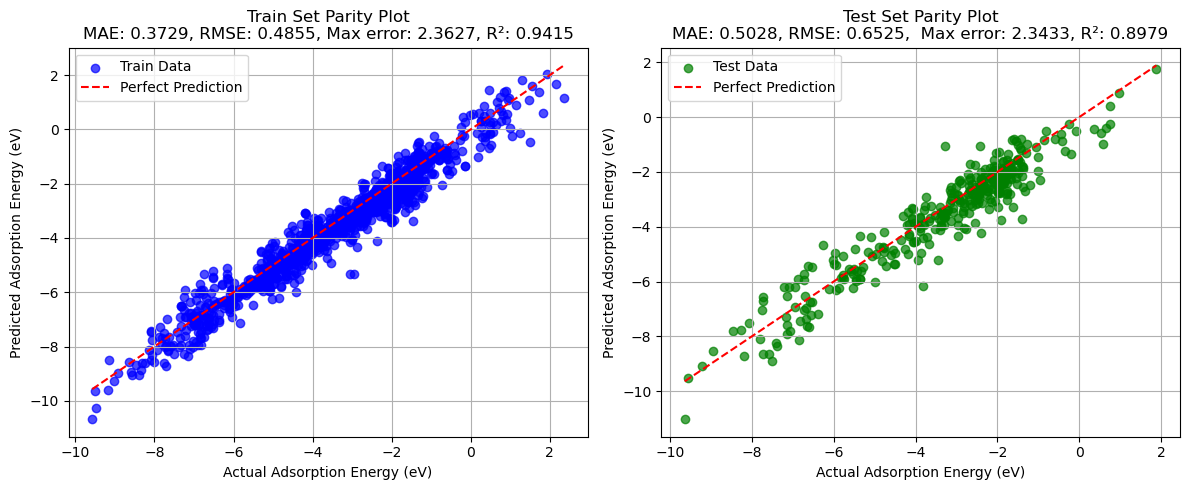


GNN framework example with train-test split and parity plots completed!


In [27]:
# Example: Run the GNN framework on the first n atoms objects with train-test split

# User-defined number of epochs
num_epochs = 100

# Best hyperparameters from tuning (update these after running the hyperparameter tuning cell above)
best_feature_dim = 32 #8
best_hidden_dim = 256 #8
best_num_layers = 2 #1
best_lr = 0.001 #0.01

# Initialize simplified model and move to device
model = GNNModel(feature_dim=best_feature_dim, hidden_dim=best_hidden_dim, output_dim=1, num_layers=best_num_layers).to(device)

# import time
# time.sleep(1) ### Added this to try to fix a weird issue with torch. Probalby not needed anymore.

# Quick training on the train samples
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
loss_fn = torch.nn.MSELoss()

print('Starting training...')
for epoch in range(num_epochs):
    total_loss = 0
    for graph in train_graphs:
        optimizer.zero_grad()
        pred = model(graph)
        loss = loss_fn(pred, graph.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_graphs)
    print(f"Epoch {epoch+1}, Avg Train Loss: {avg_loss:.4f}")



# Get targets for train and test
train_targets = [targets[graphs.index(g)] for g in train_graphs]
test_targets = [targets[graphs.index(g)] for g in test_graphs]

# Evaluate on train set
train_mae, train_rmse, train_r2, train_max_error, train_preds, train_actuals = evaluate_model(model, train_graphs, train_targets)
print(f"\nTrain Set Metrics:")
print(f"MAE: {train_mae:.4f} eV")
print(f"RMSE: {train_rmse:.4f} eV")
print(f"R²: {train_r2:.4f}")
print(f"Max error: {train_max_error:.4f} eV")


# Evaluate on test set
test_mae, test_rmse, test_r2, test_max_error, test_preds, test_actuals = evaluate_model(model, test_graphs, test_targets)
print(f"\nTest Set Metrics:")
print(f"MAE: {test_mae:.4f} eV")
print(f"RMSE: {test_rmse:.4f} eV")
print(f"R²: {test_r2:.4f}")
print(f"Max error: {test_max_error:.4f} eV")


# Parity plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Train set parity plot
ax1.scatter(train_actuals, train_preds, alpha=0.7, color='blue', label='Train Data')
ax1.plot([min(train_actuals), max(train_actuals)], [min(train_actuals), max(train_actuals)], 'r--', label='Perfect Prediction')
ax1.set_xlabel('Actual Adsorption Energy (eV)')
ax1.set_ylabel('Predicted Adsorption Energy (eV)')
ax1.set_title(f'Train Set Parity Plot\nMAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, Max error: {train_max_error:.4f}, R²: {train_r2:.4f}')
ax1.legend()
ax1.grid(True)

# Test set parity plot
ax2.scatter(test_actuals, test_preds, alpha=0.7, color='green', label='Test Data')
ax2.plot([min(test_actuals), max(test_actuals)], [min(test_actuals), max(test_actuals)], 'r--', label='Perfect Prediction')
ax2.set_xlabel('Actual Adsorption Energy (eV)')
ax2.set_ylabel('Predicted Adsorption Energy (eV)')
ax2.set_title(f'Test Set Parity Plot\nMAE: {test_mae:.4f}, RMSE: {test_rmse:.4f},  Max error: {test_max_error:.4f}, R²: {test_r2:.4f}')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nGNN framework example with train-test split and parity plots completed!")

In [58]:
run_hyperparameter_tuning = True ### A flag on whether to run this cell or not

if run_hyperparameter_tuning:
    


    import itertools

    # Hyperparameter grid
    #param_grid = {'feature_dim': [8, 16], 'hidden_dim': [4, 8], 'num_layers': [1, 2], 'lr': [0.001, 0.01]}
    param_grid = {'feature_dim': [32, 64], 'hidden_dim': [125,256], 'num_layers': [2, 4], 'lr': [0.001, 0.01]}
    param_combinations = list(itertools.product(*param_grid.values()))
    param_names = list(param_grid.keys())

    # Initialize tracking variables
    best_val_mae = float('inf')
    best_params = None
    best_model_state = None

    # Tuning parameters
    tuning_epochs = 1

    # Split train_graphs into train and val for tuning
    from sklearn.model_selection import train_test_split
    train_graphs_tune, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)

    print("Starting hyperparameter tuning...")
    for combo in param_combinations:
        params = dict(zip(param_names, combo))
        print(f"Tuning with params: {params}")
        
        # Separate model and optimizer params
        model_params = {k: v for k, v in params.items() if k != 'lr'}
        
        # Initialize model
        model = GNNModel(**model_params, output_dim=1).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
        loss_fn = torch.nn.MSELoss()
        
        # Train for tuning_epochs
        for epoch in range(tuning_epochs):
            total_loss = 0
            for graph in train_graphs_tune:
                optimizer.zero_grad()
                pred = model(graph)
                loss = loss_fn(pred, graph.y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
        
        # Evaluate on validation set
        val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, [targets[graphs.index(g)] for g in val_graphs])
        print(f"  Val MAE: {val_mae:.4f}")
        
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_params = params
            best_model_state = model.state_dict()

    print(f"Best params: {best_params}, Best Val MAE: {best_val_mae:.4f}")

    # Retrain best model on train + val with more epochs
    best_model_params = {k: v for k, v in best_params.items() if k != 'lr'}
    best_model = GNNModel(**best_model_params, output_dim=1).to(device)
    best_model.load_state_dict(best_model_state)
    optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params['lr'])
    loss_fn = torch.nn.MSELoss()

Starting hyperparameter tuning...
Tuning with params: {'feature_dim': 32, 'hidden_dim': 125, 'num_layers': 2, 'lr': 0.001}
  Val MAE: 1.0725
Tuning with params: {'feature_dim': 32, 'hidden_dim': 125, 'num_layers': 2, 'lr': 0.01}
  Val MAE: 1.0416
Tuning with params: {'feature_dim': 32, 'hidden_dim': 125, 'num_layers': 4, 'lr': 0.001}
  Val MAE: 1.0778
Tuning with params: {'feature_dim': 32, 'hidden_dim': 125, 'num_layers': 4, 'lr': 0.01}
  Val MAE: 1.1467
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.001}
  Val MAE: 1.0346
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.01}
  Val MAE: 1.0472
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 4, 'lr': 0.001}
  Val MAE: 1.0179
Tuning with params: {'feature_dim': 32, 'hidden_dim': 256, 'num_layers': 4, 'lr': 0.01}
  Val MAE: 1.2020
Tuning with params: {'feature_dim': 64, 'hidden_dim': 125, 'num_layers': 2, 'lr': 0.001}
  Val MAE: 1.0688
Tuning 

Starting training...
Epoch 1, Avg Train Loss: 2.4297
Epoch 2, Avg Train Loss: 1.9159
Epoch 3, Avg Train Loss: 1.7634
Epoch 4, Avg Train Loss: 1.6049
Epoch 5, Avg Train Loss: 1.4790
Epoch 6, Avg Train Loss: 1.3830
Epoch 7, Avg Train Loss: 1.2903
Epoch 8, Avg Train Loss: 1.2224
Epoch 9, Avg Train Loss: 1.1605
Epoch 10, Avg Train Loss: 1.1090
Epoch 11, Avg Train Loss: 1.0524
Epoch 12, Avg Train Loss: 1.0220
Epoch 13, Avg Train Loss: 0.9962
Epoch 14, Avg Train Loss: 0.9729
Epoch 15, Avg Train Loss: 0.9454
Epoch 16, Avg Train Loss: 0.9231
Epoch 17, Avg Train Loss: 0.9009
Epoch 18, Avg Train Loss: 0.8790
Epoch 19, Avg Train Loss: 0.8473
Epoch 20, Avg Train Loss: 0.8346
Epoch 21, Avg Train Loss: 0.8071
Epoch 22, Avg Train Loss: 0.7747
Epoch 23, Avg Train Loss: 0.7460
Epoch 24, Avg Train Loss: 0.7180
Epoch 25, Avg Train Loss: 0.7067
Epoch 26, Avg Train Loss: 0.6601
Epoch 27, Avg Train Loss: 0.6336
Epoch 28, Avg Train Loss: 0.6111
Epoch 29, Avg Train Loss: 0.5851
Epoch 30, Avg Train Loss: 0.550

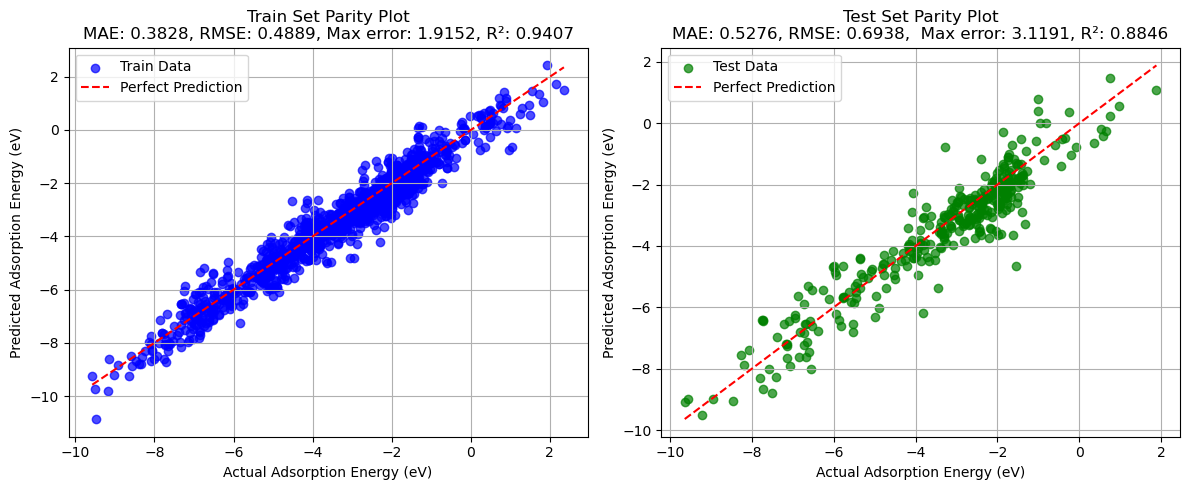


GNN framework example with train-test split and parity plots completed!


In [59]:
# Example: Run the GNN framework on the first n atoms objects with train-test split

# User-defined number of epochs
num_epochs = 100

# Best hyperparameters from tuning (update these after running the hyperparameter tuning cell above)
best_feature_dim = 32 #8
best_hidden_dim = 256 #8
best_num_layers = 4 #1
best_lr = 0.001 #0.01

# Initialize simplified model and move to device
model = GNNModel(feature_dim=best_feature_dim, hidden_dim=best_hidden_dim, output_dim=1, num_layers=best_num_layers).to(device)

# import time
# time.sleep(1) ### Added this to try to fix a weird issue with torch. Probalby not needed anymore.

# Quick training on the train samples
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
loss_fn = torch.nn.MSELoss()

print('Starting training...')
for epoch in range(num_epochs):
    total_loss = 0
    for graph in train_graphs:
        optimizer.zero_grad()
        pred = model(graph)
        loss = loss_fn(pred, graph.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_graphs)
    print(f"Epoch {epoch+1}, Avg Train Loss: {avg_loss:.4f}")



# Get targets for train and test
train_targets = [targets[graphs.index(g)] for g in train_graphs]
test_targets = [targets[graphs.index(g)] for g in test_graphs]

# Evaluate on train set
train_mae, train_rmse, train_r2, train_max_error, train_preds, train_actuals = evaluate_model(model, train_graphs, train_targets)
print(f"\nTrain Set Metrics:")
print(f"MAE: {train_mae:.4f} eV")
print(f"RMSE: {train_rmse:.4f} eV")
print(f"R²: {train_r2:.4f}")
print(f"Max error: {train_max_error:.4f} eV")


# Evaluate on test set
test_mae, test_rmse, test_r2, test_max_error, test_preds, test_actuals = evaluate_model(model, test_graphs, test_targets)
print(f"\nTest Set Metrics:")
print(f"MAE: {test_mae:.4f} eV")
print(f"RMSE: {test_rmse:.4f} eV")
print(f"R²: {test_r2:.4f}")
print(f"Max error: {test_max_error:.4f} eV")


# Parity plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Train set parity plot
ax1.scatter(train_actuals, train_preds, alpha=0.7, color='blue', label='Train Data')
ax1.plot([min(train_actuals), max(train_actuals)], [min(train_actuals), max(train_actuals)], 'r--', label='Perfect Prediction')
ax1.set_xlabel('Actual Adsorption Energy (eV)')
ax1.set_ylabel('Predicted Adsorption Energy (eV)')
ax1.set_title(f'Train Set Parity Plot\nMAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, Max error: {train_max_error:.4f}, R²: {train_r2:.4f}')
ax1.legend()
ax1.grid(True)

# Test set parity plot
ax2.scatter(test_actuals, test_preds, alpha=0.7, color='green', label='Test Data')
ax2.plot([min(test_actuals), max(test_actuals)], [min(test_actuals), max(test_actuals)], 'r--', label='Perfect Prediction')
ax2.set_xlabel('Actual Adsorption Energy (eV)')
ax2.set_ylabel('Predicted Adsorption Energy (eV)')
ax2.set_title(f'Test Set Parity Plot\nMAE: {test_mae:.4f}, RMSE: {test_rmse:.4f},  Max error: {test_max_error:.4f}, R²: {test_r2:.4f}')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nGNN framework example with train-test split and parity plots completed!")

In [30]:
sample_graph = train_graphs[0]
print(sample_graph.x.shape)  # should be [num_nodes, feature_dim]


torch.Size([37, 1])


In [31]:
import torch
from gnn_framework import GraphSample, GNNModel
from sklearn.model_selection import train_test_split
import numpy as np
import itertools

device = torch.device("cpu")
print(f"Using device: {device}")

# Automatically detect input feature size
input_dim = train_graphs[0].x.shape[1]
print(f"Node feature dimension detected: {input_dim}")

run_hyperparameter_tuning = True
if run_hyperparameter_tuning:

    param_grid = {
        'hidden_dim': [128, 256],
        'num_layers': [2, 4],
        'lr': [0.001, 0.01]
    }

    param_combinations = list(itertools.product(*param_grid.values()))
    param_names = list(param_grid.keys())

    best_val_mae = float('inf')
    best_params = None
    best_model_state = None

    patience = 5
    max_tuning_epochs = 10

    train_graphs_tune, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)

    print("Starting hyperparameter tuning...")

    for combo in param_combinations:
        params = dict(zip(param_names, combo))
        print(f"\nTuning with params: {params}")

        model = GNNModel(
            feature_dim=input_dim,   #
            hidden_dim=params['hidden_dim'],
            num_layers=params['num_layers'],
            output_dim=1
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )
        loss_fn = torch.nn.MSELoss()

        combo_best_val_mae = float('inf')
        combo_best_state = None
        counter = 0

        for epoch in range(max_tuning_epochs):
            # ---- Training ----
            model.train()
            total_loss = 0

            for graph in train_graphs_tune:
                optimizer.zero_grad()
                pred = model(graph)
                loss = loss_fn(pred, graph.y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            avg_train_loss = total_loss / len(train_graphs_tune)

            # ---- Validation ----
            val_targets_norm = [g.y.item() for g in val_graphs]
            val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, val_targets_norm)

            scheduler.step(val_mae)

            # ---- Early stopping ----
            if val_mae < combo_best_val_mae:
                combo_best_val_mae = val_mae
                combo_best_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    break

        print(f"  Best Val MAE for this combo: {combo_best_val_mae:.4f}")

        if combo_best_val_mae < best_val_mae:
            best_val_mae = combo_best_val_mae
            best_params = params
            best_model_state = combo_best_state

    print(f"\n Best params: {best_params}, Best Val MAE: {best_val_mae:.4f}")


Using device: cpu
Node feature dimension detected: 1
Starting hyperparameter tuning...

Tuning with params: {'hidden_dim': 128, 'num_layers': 2, 'lr': 0.001}
  Best Val MAE for this combo: 1.0424

Tuning with params: {'hidden_dim': 128, 'num_layers': 2, 'lr': 0.01}
  Best Val MAE for this combo: 0.8863

Tuning with params: {'hidden_dim': 128, 'num_layers': 4, 'lr': 0.001}
  Best Val MAE for this combo: 0.9754

Tuning with params: {'hidden_dim': 128, 'num_layers': 4, 'lr': 0.01}
  Best Val MAE for this combo: 0.9804

Tuning with params: {'hidden_dim': 256, 'num_layers': 2, 'lr': 0.001}
  Best Val MAE for this combo: 0.9257

Tuning with params: {'hidden_dim': 256, 'num_layers': 2, 'lr': 0.01}
  Best Val MAE for this combo: 1.0096

Tuning with params: {'hidden_dim': 256, 'num_layers': 4, 'lr': 0.001}
  Best Val MAE for this combo: 1.0922

Tuning with params: {'hidden_dim': 256, 'num_layers': 4, 'lr': 0.01}
  Best Val MAE for this combo: 1.1472

🏆 Best params: {'hidden_dim': 128, 'num_laye

Detected node feature dimension: 1
Using best params: {'hidden_dim': 128, 'num_layers': 2, 'lr': 0.01}

Starting final training (Max 200 epochs)...
Epoch 005 | Train Loss: 2.3437 | Val MAE: 1.7341
Epoch 010 | Train Loss: 2.1407 | Val MAE: 1.4551
Epoch 015 | Train Loss: 1.8818 | Val MAE: 1.1156
Epoch 020 | Train Loss: 1.7195 | Val MAE: 1.0596
Epoch 025 | Train Loss: 1.3752 | Val MAE: 0.9698
Epoch 030 | Train Loss: 1.0461 | Val MAE: 0.7811
Epoch 035 | Train Loss: 0.9602 | Val MAE: 0.7689
Epoch 040 | Train Loss: 0.9081 | Val MAE: 0.7565
Epoch 045 | Train Loss: 0.8776 | Val MAE: 0.7479
Epoch 050 | Train Loss: 0.7658 | Val MAE: 0.6633
Epoch 055 | Train Loss: 0.7507 | Val MAE: 0.6645
Epoch 060 | Train Loss: 0.7438 | Val MAE: 0.6648
Epoch 065 | Train Loss: 0.7285 | Val MAE: 0.6621
Epoch 070 | Train Loss: 0.7230 | Val MAE: 0.6402
Epoch 075 | Train Loss: 0.7079 | Val MAE: 0.6512
Epoch 080 | Train Loss: 0.6543 | Val MAE: 0.5987
Epoch 085 | Train Loss: 0.6408 | Val MAE: 0.6003
Epoch 090 | Train L

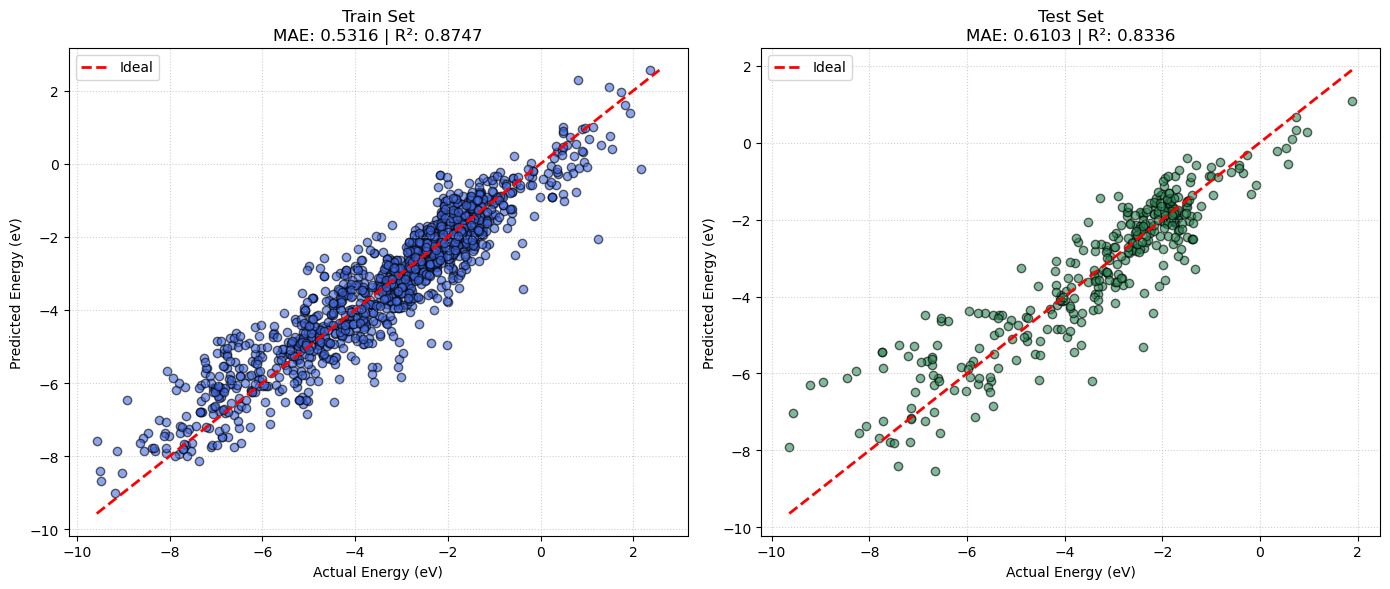


Training Complete. Final Test MAE: 0.6103 eV


In [32]:
import torch
import matplotlib.pyplot as plt

# --- 1. Detect Input Feature Size Automatically ---
input_dim = train_graphs[0].x.shape[1]
print(f"Detected node feature dimension: {input_dim}")

# --- 2. Load Best Hyperparameters (except feature_dim) ---
if 'best_params' in locals():
    best_hidden_dim = best_params['hidden_dim']
    best_num_layers = best_params['num_layers']
    best_lr = best_params['lr']
    print(f"Using best params: {best_params}")
else:
    # Fallback defaults
    best_hidden_dim, best_num_layers, best_lr = 64, 2, 0.01
    print("Warning: best_params not found. Using manual defaults.")

# --- 3. Initialize Model ---
model = GNNModel(
    feature_dim=input_dim,       
    hidden_dim=best_hidden_dim,
    output_dim=1,
    num_layers=best_num_layers
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
loss_fn = torch.nn.MSELoss()

# --- 4. Training with Early Stopping ---
num_epochs = 200
patience = 25
best_val_mae = float('inf')
best_state = None
counter = 0

print(f'\nStarting final training (Max {num_epochs} epochs)...')

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for graph in train_graphs:
        optimizer.zero_grad()
        pred = model(graph)
        loss = loss_fn(pred, graph.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_graphs)

    # --- Validation ---
    model.eval()
    val_targets = [g.y.item() for g in val_graphs]
    val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, val_targets)

    scheduler.step(val_mae)

    # --- Early Stopping ---
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Stopping early at epoch {epoch+1}. Restoring best weights.")
            model.load_state_dict(best_state)
            break

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_loss:.4f} | Val MAE: {val_mae:.4f}")

# --- 5. Final Evaluation ---
print("\n--- Final Evaluation ---")

train_targets = [g.y.item() for g in train_graphs]
test_targets = [g.y.item() for g in test_graphs]

train_metrics = evaluate_model(model, train_graphs, train_targets)
test_metrics = evaluate_model(model, test_graphs, test_targets)

train_mae, train_rmse, train_r2, train_max, train_preds, train_actuals = train_metrics
test_mae, test_rmse, test_r2, test_max, test_preds, test_actuals = test_metrics

# --- 6. Parity Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def plot_parity(ax, actual, pred, mae, r2, title, color):
    ax.scatter(actual, pred, alpha=0.6, color=color, edgecolors='k')
    lims = [min(min(actual), min(pred)), max(max(actual), max(pred))]
    ax.plot(lims, lims, 'r--', lw=2, label='Ideal')
    ax.set_xlabel('Actual Energy (eV)')
    ax.set_ylabel('Predicted Energy (eV)')
    ax.set_title(f'{title}\nMAE: {mae:.4f} | R²: {r2:.4f}')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plot_parity(ax1, train_actuals, train_preds, train_mae, train_r2, "Train Set", "royalblue")
plot_parity(ax2, test_actuals, test_preds, test_mae, test_r2, "Test Set", "seagreen")

plt.tight_layout()
plt.show()

print(f"\nTraining Complete. Final Test MAE: {test_mae:.4f} eV")
